In [107]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression

from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [109]:
data = pd.read_csv(r"C:\Users\admin\Downloads\credit_customers.csv")
data.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,4.0,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,2.0,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,3.0,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,4.0,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,4.0,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [111]:
pd.set_option('display.max_columns', None)

data.describe(include='all')

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
count,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,NaN,4,NaN,3,3,NaN,4,NaN,2,2,2
top,no checking,NaN,existing paid,radio/tv,NaN,<100,1<=X<4,NaN,male single,none,NaN,car,NaN,none,own,NaN,skilled,NaN,none,yes,good
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,NaN,332,NaN,814,713,NaN,630,NaN,596,963,700
mean,NaN,20.903000,NaN,NaN,3271.258000,NaN,NaN,2.973000,NaN,NaN,2.845000,NaN,35.546000,NaN,NaN,1.407000,NaN,1.155000,NaN,NaN,NaN
std,NaN,12.058814,NaN,NaN,2822.736876,NaN,NaN,1.118715,NaN,NaN,1.103718,NaN,11.375469,NaN,NaN,0.577654,NaN,0.362086,NaN,NaN,NaN
min,NaN,4.000000,NaN,NaN,250.000000,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,19.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
25%,NaN,12.000000,NaN,NaN,1365.500000,NaN,NaN,2.000000,NaN,NaN,2.000000,NaN,27.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
50%,NaN,18.000000,NaN,NaN,2319.500000,NaN,NaN,3.000000,NaN,NaN,3.000000,NaN,33.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,NaN
75%,NaN,24.000000,NaN,NaN,3972.250000,NaN,NaN,4.000000,NaN,NaN,4.000000,NaN,42.000000,NaN,NaN,2.000000,NaN,1.000000,NaN,NaN,NaN


In [113]:
data['class'].value_counts()

class
good    700
bad     300
Name: count, dtype: int64

In [115]:
data['class'] = np.where(data['class']!='bad',0,1)

data

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,4.0,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,0
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,2.0,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,1
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,3.0,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,0
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,4.0,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,0
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,4.0,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking,12.0,existing paid,furniture/equipment,1736.0,<100,4<=X<7,3.0,female div/dep/mar,none,4.0,real estate,31.0,none,own,1.0,unskilled resident,1.0,none,yes,0
996,<0,30.0,existing paid,used car,3857.0,<100,1<=X<4,4.0,male div/sep,none,4.0,life insurance,40.0,none,own,1.0,high qualif/self emp/mgmt,1.0,yes,yes,0
997,no checking,12.0,existing paid,radio/tv,804.0,<100,>=7,4.0,male single,none,4.0,car,38.0,none,own,1.0,skilled,1.0,none,yes,0
998,<0,45.0,existing paid,radio/tv,1845.0,<100,1<=X<4,4.0,male single,none,4.0,no known property,23.0,none,for free,1.0,skilled,1.0,yes,yes,1


# Logistic Regression model

In [118]:
data1 = data.copy()

In [120]:
data1.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

In [122]:
target_col = 'class'

for var in data1.columns:
    if var == target_col:
        continue  

    if data1[var].dtypes != object:
        
        q1 = data1[var].quantile(0.25)
        q2 = data1[var].quantile(0.5)
        q3 = data1[var].quantile(0.75)

        ranges = [-np.inf, q1, q2, q3, np.inf]
        data1['category_' + var] = pd.cut(data1[var], bins=ranges, duplicates='drop')

        grouped = data1.groupby(['category_' + var, target_col])[target_col].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data1 = data1.merge(grouped[['category_' + var, var + '_woe']], how='left', on='category_' + var)

    elif data1[var].dtypes == object:

        grouped = data1.groupby([var, target_col])[target_col].count().unstack().reset_index()

        grouped['positive_prop'] = grouped[0] / grouped[0].sum()
        grouped['negative_prop'] = grouped[1] / grouped[1].sum()

        grouped['woe'] = np.log(grouped['positive_prop'] / grouped['negative_prop'])

        grouped.rename(columns={'woe': var + '_woe'}, inplace=True)
        data1 = data1.merge(grouped[[var, var + '_woe']], how='left', on=var)

C:\Users\admin\AppData\Local\Temp\ipykernel_740\3211901814.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data1.groupby(['category_' + var, target_col])[target_col].count().unstack().reset_index()
C:\Users\admin\AppData\Local\Temp\ipykernel_740\3211901814.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = data1.groupby(['category_' + var, target_col])[target_col].count().unstack().reset_index()
C:\Users\admin\AppData\Local\Temp\ipykernel_740\3211901814.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass o

In [124]:
data1

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class,checking_status_woe,category_duration,duration_woe,credit_history_woe,purpose_woe,category_credit_amount,credit_amount_woe,savings_status_woe,employment_woe,category_installment_commitment,installment_commitment_woe,personal_status_woe,other_parties_woe,category_residence_since,residence_since_woe,property_magnitude_woe,category_age,age_woe,other_payment_plans_woe,housing_woe,category_existing_credits,existing_credits_woe,job_woe,category_num_dependents,num_dependents_woe,own_telephone_woe,foreign_worker_woe
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,4.0,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,0,-0.818099,"(-inf, 12.0]",0.467416,0.733741,0.410063,"(-inf, 1365.5]",-0.037812,0.704246,0.235566,"(3.0, 4.0]",-0.157300,0.165548,0.000525,"(3.0, 4.0]",-0.001153,0.461035,"(42.0, inf]",0.223144,0.121179,0.194156,"(1.0, 2.0]",0.115710,0.022780,"(-inf, 1.0]",-0.002816,0.098638,-0.034867
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,2.0,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,1,-0.401392,"(24.0, inf]",-0.620240,-0.088319,0.410063,"(3972.25, inf]",-0.524524,-0.271358,-0.032103,"(-inf, 2.0]",0.190473,-0.235341,0.000525,"(-inf, 2.0]",-0.017335,0.461035,"(-inf, 27.0]",-0.305191,0.121179,0.194156,"(-inf, 1.0]",-0.074877,0.022780,"(-inf, 1.0]",-0.002816,-0.064691,-0.034867
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,3.0,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,0,1.176263,"(-inf, 12.0]",0.467416,0.733741,-0.606136,"(1365.5, 2319.5]",0.262010,-0.271358,0.394415,"(-inf, 2.0]",0.190473,0.165548,0.000525,"(2.0, 3.0]",0.054941,0.461035,"(42.0, inf]",0.223144,0.121179,0.194156,"(-inf, 1.0]",-0.074877,0.097164,"(1.0, inf]",0.015409,-0.064691,-0.034867
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,4.0,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,0,-0.818099,"(24.0, inf]",-0.620240,-0.088319,-0.095557,"(3972.25, inf]",-0.524524,-0.271358,0.394415,"(-inf, 2.0]",0.190473,0.165548,0.587787,"(3.0, 4.0]",-0.001153,-0.028573,"(42.0, inf]",0.223144,0.121179,-0.472604,"(-inf, 1.0]",-0.074877,0.022780,"(1.0, inf]",0.015409,-0.064691,-0.034867
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,4.0,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,1,-0.818099,"(18.0, 24.0]",0.025642,-0.085158,-0.359200,"(3972.25, inf]",-0.524524,-0.271358,-0.032103,"(2.0, 3.0]",0.064539,0.165548,0.000525,"(3.0, 4.0]",-0.001153,-0.586082,"(42.0, inf]",0.223144,0.121179,-0.472604,"(1.0, 2.0]",0.115710,0.022780,"(1.0, inf]",0.015409,-0.064691,-0.034867
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking,12.0,existing paid,furniture/equipment,1736.0,<100,4<=X<7,3.0,female div/dep/mar,none,4.0,real estate,31.0,none,own,1.0,unskilled resident,1.0,none,yes,0,1.176263,"(-inf, 12.0]",0.467416,-0.088319,-0.095557,"(1365.5, 2319.5]",0.262010,-0.271358,0.394415,"(2.0, 3.0]",0.064539,-0.235341,0.000525,"(3.0, 4.0]",-0.001153,0.461035,"(27.0, 33.0]",-0.134083,0.121179,0.194156,"(-inf, 1.0]",-0.074877,0.097164,"(-inf, 1.0]",-0.002816,-0.064691,-0.034867
996,<0,30.0,existing paid,used car,3857.0,<100,1<=X<4,4.0,male div/sep,none,4.0,life insurance,40.0,none,own,1.0,high qualif/self emp/mgmt,1.0,yes,yes,0,-0.818099,"(24.0, inf]",-0.620240,-0.088319,0.773836,"(2319.5, 3972.25]",0.395209,-0.271358,-0.032103,"(3.0, 4.0]",-0.157300,-0.441833,0.000525,"(3.0, 4.0]",-0.001153,-0.028573,"(33.0

In [126]:
from scipy import stats


for i in data1.columns:
    
    if data1[i].dtype in ['int64', 'float64']:

        kstest_statistic, kstest_p_value = stats.kstest(data1[i], 'norm')
        # 'norm' inside indicates that the test is comparing the distribution of the data against a normal distribution
        
        print(f'Column: {i}')
        print(f'Kolmogorov-Smirnov Test:')
        print(f'Test Statistic: {kstest_statistic}')
        print(f'p-value: {kstest_p_value}')
        
        if kstest_p_value > 0.05:
            print('Data looks normally distributed')
            print()
        else:
            print('Data does not look normally distributed')
            print()

Column: duration
Kolmogorov-Smirnov Test:
Test Statistic: 0.9999683287581669
p-value: 0.0
Data does not look normally distributed

Column: credit_amount
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: installment_commitment
Kolmogorov-Smirnov Test:
Test Statistic: 0.8413447460685429
p-value: 0.0
Data does not look normally distributed

Column: residence_since
Kolmogorov-Smirnov Test:
Test Statistic: 0.8472498680518208
p-value: 0.0
Data does not look normally distributed

Column: age
Kolmogorov-Smirnov Test:
Test Statistic: 1.0
p-value: 0.0
Data does not look normally distributed

Column: existing_credits
Kolmogorov-Smirnov Test:
Test Statistic: 0.8413447460685429
p-value: 0.0
Data does not look normally distributed

Column: num_dependents
Kolmogorov-Smirnov Test:
Test Statistic: 0.8413447460685429
p-value: 0.0
Data does not look normally distributed

Column: checking_status_woe
Kolmogorov-Smirnov Test:
Test Statistic: 0.2742551

In [128]:
def target_correlation(data1, target, threshold=0.1):
    
    woe_features = data1.filter(regex='_woe$', axis=1)  # Select only _woe features
    woe_features[target] = data1[target] 
    
    corr_matrix = woe_features.corr(method='spearman')
    
    target_correlations = corr_matrix[target].abs() > threshold
    
    variables_explaining_target = target_correlations[target_correlations].index.tolist()

    variables_explaining_target.remove(target)
    
    result_explaining_target = pd.DataFrame(
    {'Variable': variables_explaining_target,
    'Correlation with Target': corr_matrix.loc[variables_explaining_target, target]})
    
    result_explaining_target.reset_index(drop=True, inplace=True)
    
    return result_explaining_target


target_result = target_correlation(data1, 'class')

target_result

C:\Users\admin\AppData\Local\Temp\ipykernel_740\2085733294.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  woe_features[target] = data1[target]


,Variable,Correlation with Target
0,checking_status_woe,-0.347944
1,duration_woe,-0.179965
2,credit_history_woe,-0.221606
3,purpose_woe,-0.179875
4,credit_amount_woe,-0.158096
5,savings_status_woe,-0.178989
6,employment_woe,-0.132734
7,property_magnitude_woe,-0.140851
8,age_woe,-0.116511
9,other_payment_plans_woe,-0.113046


In [130]:

def intercorrelation(data1, target, threshold=0.7):
    
    woe_features = data1.filter(regex='_woe$', axis=1) 
    
    corr_matrix = woe_features.corr(method='spearman')
    
    highly_correlated_variables = (np.abs(corr_matrix) > threshold) & (corr_matrix != 1.0)
    
    independent_variable_pairs = np.where(highly_correlated_variables)
    
    correlated_pairs_set = set()
   
    for var1, var2 in zip(independent_variable_pairs[0], independent_variable_pairs[1]):

        if var1 < var2:
            correlated_pairs_set.add((corr_matrix.index[var1], corr_matrix.columns[var2]))
        else:
            correlated_pairs_set.add((corr_matrix.index[var2], corr_matrix.columns[var1]))
            
   # print(correlated_pairs_set)
    
    result_intercorrelated_independent = pd.DataFrame(list(correlated_pairs_set), columns=['Variable 1', 'Variable 2'])
    
    return result_intercorrelated_independent

# Example usage
intercorrelated_result = intercorrelation(data1, 'class')
intercorrelated_result


,Variable 1,Variable 2


In [132]:
target_result.Variable.tolist()

['checking_status_woe',
 'duration_woe',
 'credit_history_woe',
 'purpose_woe',
 'credit_amount_woe',
 'savings_status_woe',
 'employment_woe',
 'property_magnitude_woe',
 'age_woe',
 'other_payment_plans_woe',
 'housing_woe']

In [134]:
inputs = data1.filter(regex='_woe$', axis=1)
output=data1['class']

In [136]:
X_train, X_test, y_train, y_test = train_test_split(inputs, output, test_size=0.2, random_state=42)

In [138]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

def evaluate(model, X_train, y_train, X_test, y_test):
    
    '''Predictions and probabilities for the training set'''
    
    y_train_pred = model.predict(X_train)
    y_train_prob = model.predict_proba(X_train)[:, 1]

    '''Predictions and probabilities for the test set'''
    
    y_test_pred = model.predict(X_test)
    y_test_prob = model.predict_proba(X_test)[:, 1]

    '''Calculate metrics for the training set''' 
    
    roc_train_prob = roc_auc_score(y_train, y_train_prob)
    gini_train_prob = roc_train_prob * 2 - 1
    precision_train = precision_score(y_train, y_train_pred)
    recall_train = recall_score(y_train, y_train_pred)

    '''Calculate metrics for the test set'''
    
    roc_test_prob = roc_auc_score(y_test, y_test_prob)
    gini_test_prob = roc_test_prob * 2 - 1
    precision_test = precision_score(y_test, y_test_pred)
    recall_test = recall_score(y_test, y_test_pred)

    results = pd.DataFrame({
        'Dataset': ['Train', 'Test'],
        'Gini': [gini_train_prob * 100, gini_test_prob * 100],
        'Precision': [precision_train, precision_test],
        'Recall': [recall_train, recall_test]
    })

    confusion_matrix = metrics.confusion_matrix(y_test, y_test_pred)
    
    return results , confusion_matrix

In [140]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [142]:
result = evaluate(clf, X_train, y_train, X_test, y_test)

result

(  Dataset       Gini  Precision    Recall
 0   Train  64.457129   0.640719  0.443983
 1    Test  66.774853   0.673469  0.559322,
 array([[125,  16],
        [ 26,  33]], dtype=int64))

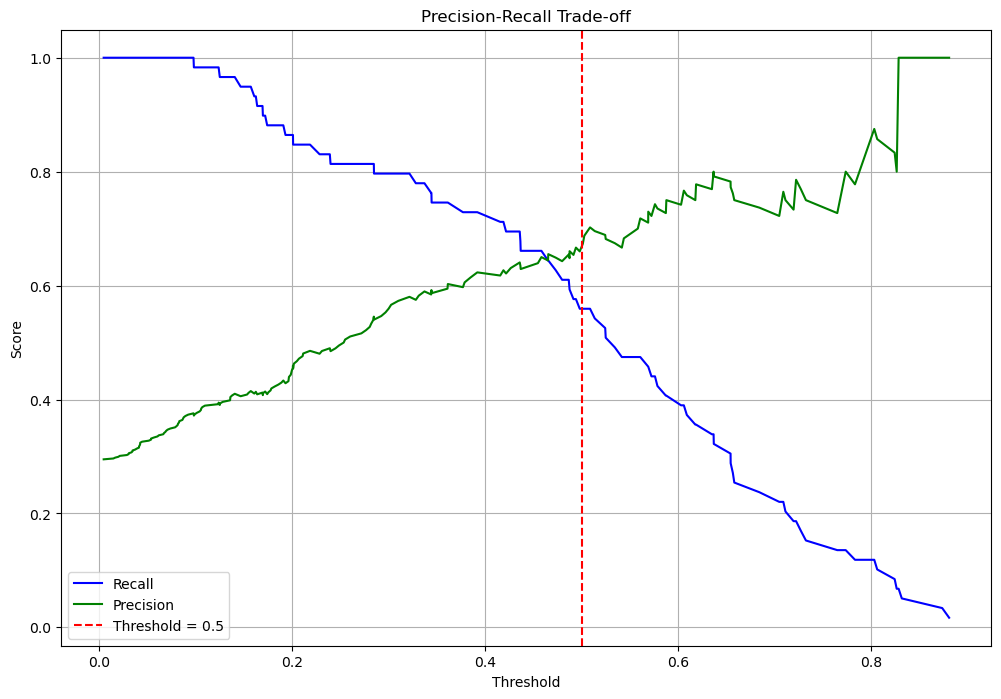

In [144]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

y_prob = clf.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(12, 8))
plt.plot(thresholds, recall[:-1], label='Recall', color='blue')
plt.plot(thresholds, precision[:-1], label='Precision', color='green')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold = 0.5')
plt.legend()
plt.grid(True)
plt.show()

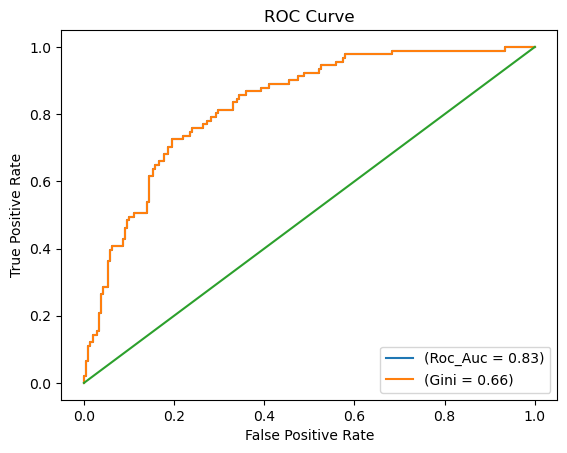

In [246]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

y_prob = clf.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_prob)
gini = (2*roc_auc_score(y_test, y_prob))-1

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure()

plt.plot(fpr, tpr, label='(Roc_Auc = %0.2f)' % roc_auc)
plt.plot(fpr, tpr, label='(Gini = %0.2f)' % gini)
plt.plot([0, 1], [0, 1])
plt.xlim()
plt.ylim()

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

plt.legend(loc='lower right')
plt.show()

In [248]:
import pandas as pd
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Create lists to store the variables, ROC AUC scores, and Gini scores
variables = []
train_gini_scores = []
test_gini_scores = []


for i in X_train.columns:
    X_train_single_var = X_train[[i]]
    X_test_single_var = X_test[[i]]

    # Fit a classifier using the single variable on the training set
    clf.fit(X_train_single_var, y_train)
    y_pred_train_single_var = clf.predict_proba(X_train_single_var)[:, 1]

    # Calculate ROC AUC score for the single variable model on the training set
    train_roc = roc_auc_score(y_train, y_pred_train_single_var)

    # Calculate Gini score for the single variable model on the training set
    train_gini = 2 * train_roc - 1

    # Fit a classifier using the single variable on the test set
    y_pred_test_single_var = clf.predict_proba(X_test_single_var)[:, 1]

    # Calculate ROC AUC score for the single variable model on the test set
    test_roc = roc_auc_score(y_test, y_pred_test_single_var)

    # Calculate Gini score for the single variable model on the test set
    test_gini = 2 * test_roc - 1

    # Append the results to the lists
    variables.append(i)
    train_gini_scores.append(train_gini)
    test_gini_scores.append(test_gini)

# Create a DataFrame from the results
results_df = pd.DataFrame({
    'Variable': variables,
    'Train Gini': train_gini_scores,
    'Test Gini': test_gini_scores
})

# Sort the DataFrame by Test Gini score in descending order
results_df_sorted = results_df.sort_values(by='Test Gini', ascending=False)

# Display the results
pd.options.display.float_format = '{:.4f}'.format
#pd.options.display.float_format = '{:.4%}'.format


results_df_sorted


,Variable,Train Gini,Test Gini
0,checking_status_woe,0.3933,0.4651
1,duration_woe,0.1940,0.2769
6,employment_woe,0.1204,0.2568
5,savings_status_woe,0.1761,0.2517
7,installment_commitment_woe,0.0547,0.1527
13,other_payment_plans_woe,0.0733,0.1504
4,credit_amount_woe,0.2119,0.1487
2,credit_history_woe,0.3001,0.1423
3,purpose_woe,0.2592,0.1314
11,property_magnitude_woe,0.1929,0.1195


In [250]:
inputs = data1[['checking_status_woe', 'duration_woe', 'employment_woe',
       'savings_status_woe']]
output = data1['class']

In [253]:
X_train, X_test, y_train, y_test = train_test_split(inputs, output, test_size=0.3, random_state=42)

In [255]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [257]:
result = evaluate(clf, X_train, y_train, X_test, y_test)
result

(  Dataset    Gini  Precision  Recall
 0   Train 49.6370     0.6261  0.3445
 1    Test 60.9548     0.6727  0.4066,
 array([[191,  18],
        [ 54,  37]], dtype=int64))

# Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_text

data2 = data.copy()

In [14]:
data2.describe(include='all')

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
count,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000.000000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,NaN,4,NaN,3,3,NaN,4,NaN,2,2,NaN
top,no checking,NaN,existing paid,radio/tv,NaN,<100,1<=X<4,NaN,male single,none,NaN,car,NaN,none,own,NaN,skilled,NaN,none,yes,NaN
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,NaN,332,NaN,814,713,NaN,630,NaN,596,963,NaN
mean,NaN,20.903000,NaN,NaN,3271.258000,NaN,NaN,2.973000,NaN,NaN,2.845000,NaN,35.546000,NaN,NaN,1.407000,NaN,1.155000,NaN,NaN,0.300000
std,NaN,12.058814,NaN,NaN,2822.736876,NaN,NaN,1.118715,NaN,NaN,1.103718,NaN,11.375469,NaN,NaN,0.577654,NaN,0.362086,NaN,NaN,0.458487
min,NaN,4.000000,NaN,NaN,250.000000,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,19.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,0.000000
25%,NaN,12.000000,NaN,NaN,1365.500000,NaN,NaN,2.000000,NaN,NaN,2.000000,NaN,27.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,0.000000
50%,NaN,18.000000,NaN,NaN,2319.500000,NaN,NaN,3.000000,NaN,NaN,3.000000,NaN,33.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,0.000000
75%,NaN,24.000000,NaN,NaN,3972.250000,NaN,NaN,4.000000,NaN,NaN,4.000000,NaN,42.000000,NaN,NaN,2.000000,NaN,1.000000,NaN,NaN,1.000000


In [16]:
data2.corr(method='spearman', numeric_only=True)['class']

duration                  0.205685
credit_amount             0.087083
installment_commitment    0.073690
residence_since           0.002553
age                      -0.112191
existing_credits         -0.047316
num_dependents           -0.003015
class                     1.000000
Name: class, dtype: float64

In [18]:
for i in data2.columns:
    if data2[i].dtypes==object:
        print(i)

checking_status
credit_history
purpose
savings_status
employment
personal_status
other_parties
property_magnitude
other_payment_plans
housing
job
own_telephone
foreign_worker


In [20]:
data2.describe(include='all')

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
count,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000.000000,1000,1000.000000,1000,1000,1000.000000
unique,4,NaN,5,10,NaN,5,5,NaN,4,3,NaN,4,NaN,3,3,NaN,4,NaN,2,2,NaN
top,no checking,NaN,existing paid,radio/tv,NaN,<100,1<=X<4,NaN,male single,none,NaN,car,NaN,none,own,NaN,skilled,NaN,none,yes,NaN
freq,394,NaN,530,280,NaN,603,339,NaN,548,907,NaN,332,NaN,814,713,NaN,630,NaN,596,963,NaN
mean,NaN,20.903000,NaN,NaN,3271.258000,NaN,NaN,2.973000,NaN,NaN,2.845000,NaN,35.546000,NaN,NaN,1.407000,NaN,1.155000,NaN,NaN,0.300000
std,NaN,12.058814,NaN,NaN,2822.736876,NaN,NaN,1.118715,NaN,NaN,1.103718,NaN,11.375469,NaN,NaN,0.577654,NaN,0.362086,NaN,NaN,0.458487
min,NaN,4.000000,NaN,NaN,250.000000,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,19.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,0.000000
25%,NaN,12.000000,NaN,NaN,1365.500000,NaN,NaN,2.000000,NaN,NaN,2.000000,NaN,27.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,0.000000
50%,NaN,18.000000,NaN,NaN,2319.500000,NaN,NaN,3.000000,NaN,NaN,3.000000,NaN,33.000000,NaN,NaN,1.000000,NaN,1.000000,NaN,NaN,0.000000
75%,NaN,24.000000,NaN,NaN,3972.250000,NaN,NaN,4.000000,NaN,NaN,4.000000,NaN,42.000000,NaN,NaN,2.000000,NaN,1.000000,NaN,NaN,1.000000


In [22]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = ['own_telephone', 'foreign_worker', 'housing', 'other_payment_plans', 
        'property_magnitude', 'other_parties', 'personal_status', 'purpose', 'credit_history']

data2[cols] = data2[cols].apply(lambda col: le.fit_transform(col))

data2

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,1,6,1169.0,no known savings,>=7,4.0,3,2,4.0,3,67.0,1,1,2.0,skilled,1.0,1,1,0
1,0<=X<200,48.0,3,6,5951.0,<100,1<=X<4,2.0,0,2,2.0,3,22.0,1,1,1.0,skilled,1.0,0,1,1
2,no checking,12.0,1,2,2096.0,<100,4<=X<7,2.0,3,2,3.0,3,49.0,1,1,1.0,unskilled resident,2.0,0,1,0
3,<0,42.0,3,3,7882.0,<100,4<=X<7,2.0,3,1,4.0,1,45.0,1,0,1.0,skilled,2.0,0,1,0
4,<0,24.0,2,4,4870.0,<100,1<=X<4,3.0,3,2,4.0,2,53.0,1,0,2.0,skilled,2.0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no checking,12.0,3,3,1736.0,<100,4<=X<7,3.0,0,2,4.0,3,31.0,1,1,1.0,unskilled resident,1.0,0,1,0
996,<0,30.0,3,9,3857.0,<100,1<=X<4,4.0,1,2,4.0,1,40.0,1,1,1.0,high qualif/self emp/mgmt,1.0,1,1,0
997,no checking,12.0,3,6,804.0,<100,>=7,4.0,3,2,4.0,0,38.0,1,1,1.0,skilled,1.0,0,1,0
998,<0,45.0,3,6,1845.0,<100,1<=X<4,4.0,3,2,4.0,2,23.0,1,0,1.0,skilled,1.0,1,1,1


In [24]:
data2['employment'].value_counts()

employment
1<=X<4        339
>=7           253
4<=X<7        174
<1            172
unemployed     62
Name: count, dtype: int64

In [26]:
values_for_mapping = {
    "job": {
        "skilled": 3,
        "unskilled resident": 2,
        "high qualif/self emp/mgmt": 4,
        "unemp/unskilled non res": 1
    },
    "employment": {
        "<1": 2,
        "1<=X<4": 3,
        "4<=X<7": 4,
        ">=7": 5,
        "unemployed": 1,
    },
    "savings_status": {
        '<100': 2,             
        'no known savings': 1,  
        '100<=X<500': 3,       
        '500<=X<1000': 4,      
        '>=1000': 5
    },
    "checking_status": {
        '<0': 2,             
        'no checking': 1,  
        '0<=X<200': 3,       
        '>=200': 4
    }
} 

for col, mapping in values_for_mapping.items(): 
    data2[col] = data2[col].map(mapping)

data2

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,2,6.0,1,6,1169.0,1,5,4.0,3,2,4.0,3,67.0,1,1,2.0,3,1.0,1,1,0
1,3,48.0,3,6,5951.0,2,3,2.0,0,2,2.0,3,22.0,1,1,1.0,3,1.0,0,1,1
2,1,12.0,1,2,2096.0,2,4,2.0,3,2,3.0,3,49.0,1,1,1.0,2,2.0,0,1,0
3,2,42.0,3,3,7882.0,2,4,2.0,3,1,4.0,1,45.0,1,0,1.0,3,2.0,0,1,0
4,2,24.0,2,4,4870.0,2,3,3.0,3,2,4.0,2,53.0,1,0,2.0,3,2.0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,12.0,3,3,1736.0,2,4,3.0,0,2,4.0,3,31.0,1,1,1.0,2,1.0,0,1,0
996,2,30.0,3,9,3857.0,2,3,4.0,1,2,4.0,1,40.0,1,1,1.0,4,1.0,1,1,0
997,1,12.0,3,6,804.0,2,5,4.0,3,2,4.0,0,38.0,1,1,1.0,3,1.0,0,1,0
998,2,45.0,3,6,1845.0,2,3,4.0,3,2,4.0,2,23.0,1,0,1.0,3,1.0,1,1,1


In [28]:
data2.isnull().sum()

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
class                     0
dtype: int64

In [30]:
data2.columns

Index(['checking_status', 'duration', 'credit_history', 'purpose',
       'credit_amount', 'savings_status', 'employment',
       'installment_commitment', 'personal_status', 'other_parties',
       'residence_since', 'property_magnitude', 'age', 'other_payment_plans',
       'housing', 'existing_credits', 'job', 'num_dependents', 'own_telephone',
       'foreign_worker', 'class'],
      dtype='object')

In [32]:
y=data2['class']
x=data2.drop('class', axis=1)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [36]:
from sklearn import metrics

def evaluate(model,X_train, y_train, X_test, y_test):
    
    y_pred = model.predict(X_test)
    
    mae_test = metrics.mean_absolute_error(y_test, y_pred)
    mse_test = metrics.mean_squared_error(y_test, y_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = metrics.r2_score(y_test, y_pred)


    y_pred_train = model.predict(X_train)

    mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
    mse_train = metrics.mean_squared_error(y_train, y_pred_train)
    rmse_train = np.sqrt(mse_train)
    r2_train = metrics.r2_score(y_train, y_pred_train)


    results_dict = {
        'Metric': ['MAE', 'MSE', 'RMSE', 'R2'],
        'Train': [mae_train, mse_train, rmse_train, r2_train*100],
        'Test': [mae_test, mse_test, rmse_test, r2_test*100]
    }

    results_df = pd.DataFrame(results_dict)
    
    return results_df

In [42]:
reg = RandomForestRegressor(random_state=42)
reg.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [44]:
evaluate(reg, X_train, y_train, X_test, y_test)

,Metric,Train,Test
0,MAE,0.123725,0.306350
1,MSE,0.024026,0.146308
2,RMSE,0.155004,0.382503
3,R2,88.586020,29.650920


In [48]:
def plot_feature_importances(model, feature_names):
    
    importances = model.feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values(by="Importance", ascending=False)
   
    
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.title("Feature Importances")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.gca().invert_yaxis() 
    plt.show()
    
    return importance_df

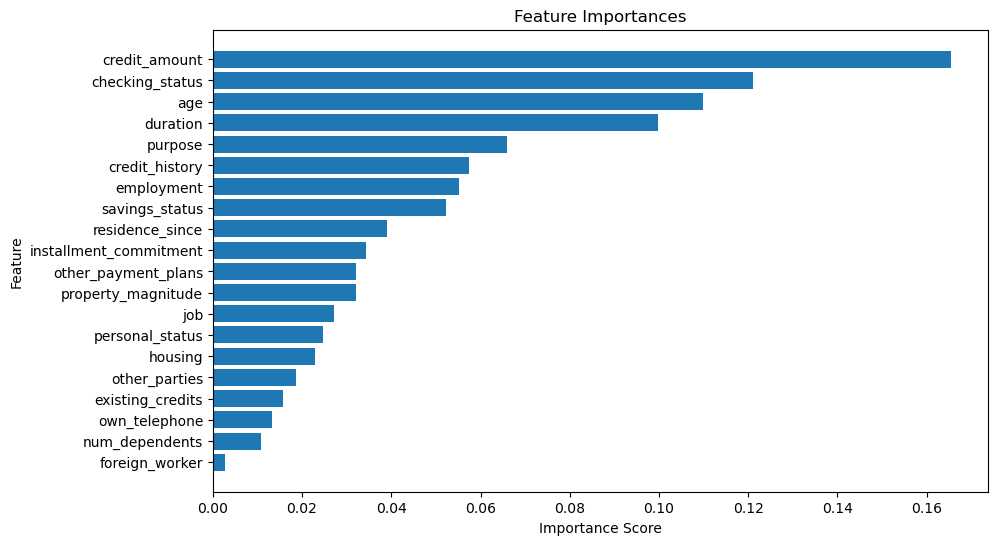

,Feature,Importance
4,credit_amount,0.165461
0,checking_status,0.121112
12,age,0.109818
1,duration,0.099848
3,purpose,0.065836
2,credit_history,0.057415
6,employment,0.055094
5,savings_status,0.052237
10,residence_since,0.039000
7,installment_commitment,0.034347


In [54]:
feature_names = X_train.columns

feature_importance_df = plot_feature_importances(reg, feature_names)

feature_importance_df

In [56]:
feature_importance_df.Feature.tolist()

['credit_amount',
 'checking_status',
 'age',
 'duration',
 'purpose',
 'credit_history',
 'employment',
 'savings_status',
 'residence_since',
 'installment_commitment',
 'other_payment_plans',
 'property_magnitude',
 'job',
 'personal_status',
 'housing',
 'other_parties',
 'existing_credits',
 'own_telephone',
 'num_dependents',
 'foreign_worker']

In [96]:
reg_selected = RandomForestRegressor(random_state=42)

reg_selected.fit(X_train[['credit_amount',
 'checking_status',
 'age',
 'duration']],y_train)

RandomForestRegressor(random_state=42)

In [98]:
evaluate(reg_selected,X_train[['credit_amount',
 'checking_status',
 'age',
 'duration']],y_train, 
         X_test[['credit_amount',
 'checking_status',
 'age',
 'duration']], y_test)

,Metric,Train,Test
0,MAE,0.130075,0.317800
1,MSE,0.027822,0.167318
2,RMSE,0.166799,0.409045
3,R2,86.782919,19.548984


In [68]:
from sklearn.model_selection import RandomizedSearchCV

n_estimators = [int(x) for x in np.linspace(start = 200, stop = 1000, num = 10)]
max_depth = [int(x) for x in np.linspace(10, 100, num = 11)]

# Create the random grid
random_grid = {'n_estimators': n_estimators, # Number of trees in random forest
               'max_features': ['sqrt', 0.3, 0.5, None], # Number of features to consider at every split
               'max_depth': max_depth, # Maximum number of levels in tree
               'min_samples_split': [20,50], # Minimum number of samples required to split a node
               'min_samples_leaf': [5, 8, 10]} # Minimum number of samples required at each leaf node

In [100]:
rf_random = RandomizedSearchCV(estimator = reg, param_distributions = random_grid, n_iter = 10, cv = 3, verbose=1, random_state=42, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train[['credit_amount',
 'checking_status',
 'age',
 'duration']], y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\admin\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_jobs=-1,
                   param_distributions={'max_depth': [10, 19, 28, 37, 46, 55,
                                                      64, 73, 82, 91, 100],
                                        'max_features': ['sqrt', 0.3, 0.5,
                                                         None],
                                        'min_samples_leaf': [5, 8, 10],
                                        'min_samples_split': [20, 50],
                                        'n_estimators': [200, 288, 377, 466,
                                                         555, 644, 733, 822,
                                                         911, 1000]},
                   random_state=42, verbose=1)

In [76]:
rf_random.best_params_

{'n_estimators': 1000,
 'min_samples_split': 20,
 'min_samples_leaf': 5,
 'max_features': 'sqrt',
 'max_depth': 91}

In [103]:
optimized_model = rf_random.best_estimator_

evaluate(optimized_model, X_train[['credit_amount',
 'checking_status',
 'age',
 'duration']],y_train, 
  X_test[['credit_amount',
 'checking_status',
 'age',
 'duration']], y_test)


,Metric,Train,Test
0,MAE,0.344834,0.354585
1,MSE,0.159082,0.167318
2,RMSE,0.398851,0.409046
3,R2,24.426015,19.548755
